# 03 - Baseline Modeli (Naive Bayes & SVM)

**Cilj**: Trenirati i evaluirati baseline machine learning modele

**Modeli**:
1. Naive Bayes (sa TF-IDF)
2. SVM (Support Vector Machine)

**Koraci**:
1. Učitavanje preprocesiranih podataka
2. Treniranje Naive Bayes modela
3. Treniranje SVM modela  
4. Evaluacija i poređenje rezultata
5. Čuvanje najboljih modela

In [1]:
# Import biblioteka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
sys.path.append('../src')

from models import NaiveBayesModel, SVMModel
from evaluation import (
    evaluate_model, 
    print_evaluation_report,
    plot_confusion_matrix,
    plot_metrics_comparison,
    create_results_table,
    plot_sentiment_distribution
)
from utils import save_model, save_metrics, save_figure, set_style

# Postavi stil
set_style()

print("✅ Biblioteke učitane uspešno!")

✅ Biblioteke učitane uspešno!


## 1. Učitavanje Podataka

In [2]:
# Učitaj train i test podatke
train_df = pd.read_csv('../data/processed/train_data.csv')
test_df = pd.read_csv('../data/processed/test_data.csv')

print("📊 UČITAVANJE PODATAKA")
print("="*60)
print(f"Train set: {train_df.shape}")
print(f"Test set:  {test_df.shape}")
print("\nKolone:", train_df.columns.tolist())

📊 UČITAVANJE PODATAKA
Train set: (77, 2)
Test set:  (20, 2)

Kolone: ['text', 'sentiment']


In [3]:
# Pripremi X i y
X_train = train_df['text']
y_train = train_df['sentiment']

X_test = test_df['text']
y_test = test_df['sentiment']

print("\n📈 DISTRIBUCIJA SENTIMENTA")
print("="*60)
print("\nTrain set:")
print(y_train.value_counts())
print(f"\nProcenat:")
print((y_train.value_counts() / len(y_train) * 100).round(2))

print("\nTest set:")
print(y_test.value_counts())
print(f"\nProcenat:")
print((y_test.value_counts() / len(y_test) * 100).round(2))


📈 DISTRIBUCIJA SENTIMENTA

Train set:
sentiment
positive    26
neutral     26
negative    25
Name: count, dtype: int64

Procenat:
sentiment
positive    33.77
neutral     33.77
negative    32.47
Name: count, dtype: float64

Test set:
sentiment
negative    7
positive    7
neutral     6
Name: count, dtype: int64

Procenat:
sentiment
negative    35.0
positive    35.0
neutral     30.0
Name: count, dtype: float64


In [4]:
# Proveri primere
print("\n🔍 PRIMERI IZ TRAIN SETA")
print("="*60)
for i in range(3):
    print(f"\n[Primer {i+1}]")
    print(f"Text: {X_train.iloc[i]}")
    print(f"Sentiment: {y_train.iloc[i]}")
    print("-" * 60)


🔍 PRIMERI IZ TRAIN SETA

[Primer 1]
Text: bitcoin going moon best investment ever
Sentiment: positive
------------------------------------------------------------

[Primer 2]
Text: bitcoin k yesterday
Sentiment: neutral
------------------------------------------------------------

[Primer 3]
Text: satoshi nakamoto mined first bitcoin block
Sentiment: neutral
------------------------------------------------------------


## 2. Model 1: Naive Bayes

Naive Bayes je jednostavan ali efikasan probabilistički klasifikator koji dobro radi na tekstualnim podacima.

In [5]:
# Inicijalizuj Naive Bayes model
print("\n" + "="*60)
print("NAIVE BAYES MODEL")
print("="*60)

nb_model = NaiveBayesModel(max_features=5000)
print("\n✅ Model inicijalizovan")
print("Parametri:")
print("  - TF-IDF max_features: 5000")
print("  - Classifier: MultinomialNB")


NAIVE BAYES MODEL

✅ Model inicijalizovan
Parametri:
  - TF-IDF max_features: 5000
  - Classifier: MultinomialNB


In [6]:
# Treniranje Naive Bayes
print("\n⏱️  Pokretanje treniranja...\n")
start_time = time.time()

nb_model.train(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ Treniranje završeno za {training_time:.2f} sekundi")


⏱️  Pokretanje treniranja...

Treniranje Naive Bayes modela...
Treniranje završeno!

✅ Treniranje završeno za 0.00 sekundi


In [7]:
# Predikcija na test setu
print("\n🔮 Predikcija na test setu...")
y_pred_nb = nb_model.predict(X_test)
print(f"✅ Predikcija završena: {len(y_pred_nb)} primeraka")


🔮 Predikcija na test setu...
✅ Predikcija završena: 20 primeraka


In [8]:
# Evaluacija Naive Bayes
nb_metrics = print_evaluation_report(y_test, y_pred_nb, "Naive Bayes")


EVALUACIJA MODELA: Naive Bayes
Accuracy:  0.5500 (55.00%)
Precision: 0.6343
Recall:    0.5500
F1-Score:  0.5204

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.29      0.40         7
     neutral       0.46      1.00      0.63         6
    positive       0.75      0.43      0.55         7

    accuracy                           0.55        20
   macro avg       0.63      0.57      0.53        20
weighted avg       0.63      0.55      0.52        20




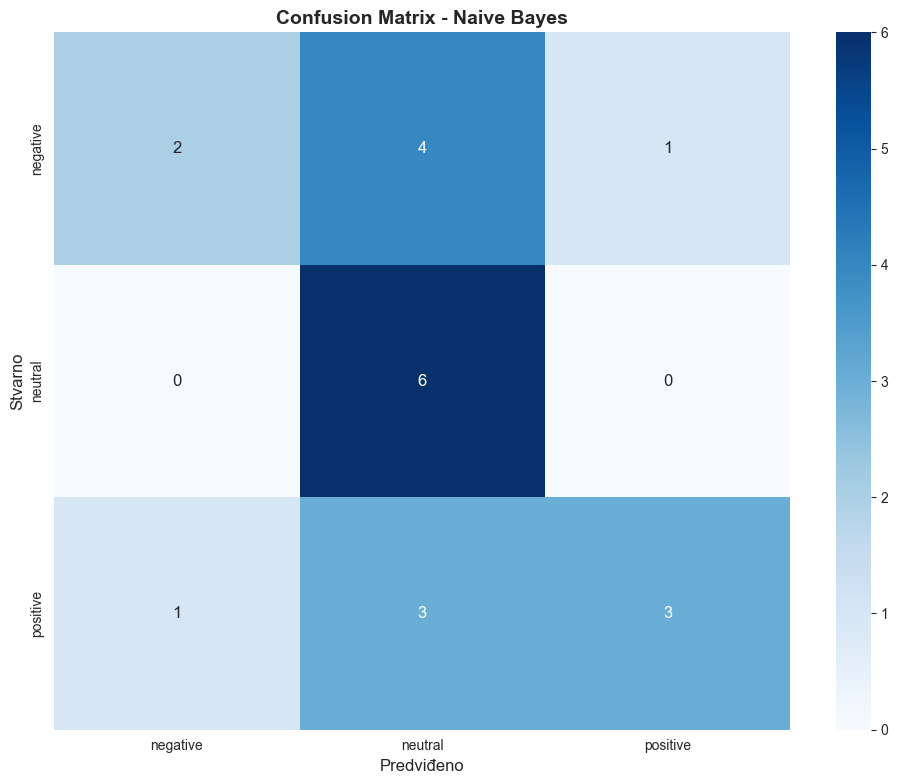

Grafik sačuvan: results/figures/nb_confusion_matrix.png


In [9]:
# Confusion Matrix za Naive Bayes
sentiment_labels = sorted(y_test.unique())
fig_nb_cm = plot_confusion_matrix(y_test, y_pred_nb, labels=sentiment_labels, model_name="Naive Bayes")
plt.show()

# Sačuvaj
save_figure(fig_nb_cm, 'nb_confusion_matrix.png')

## 3. Model 2: SVM (Support Vector Machine)

SVM je moćniji model koji može uhvatiti kompleksnije odnose u podacima.

In [10]:
# Inicijalizuj SVM model
print("\n" + "="*60)
print("SVM MODEL")
print("="*60)

svm_model = SVMModel(max_features=5000, kernel='rbf', C=1.0)
print("\n✅ Model inicijalizovan")
print("Parametri:")
print("  - TF-IDF max_features: 5000")
print("  - Kernel: RBF (Radial Basis Function)")
print("  - C (regularization): 1.0")


SVM MODEL

✅ Model inicijalizovan
Parametri:
  - TF-IDF max_features: 5000
  - Kernel: RBF (Radial Basis Function)
  - C (regularization): 1.0


In [11]:
# Treniranje SVM
print("\n⏱️  Pokretanje treniranja...\n")
print("⚠️  NAPOMENA: SVM može trajati duže od Naive Bayes\n")
start_time = time.time()

svm_model.train(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ Treniranje završeno za {training_time:.2f} sekundi")


⏱️  Pokretanje treniranja...

⚠️  NAPOMENA: SVM može trajati duže od Naive Bayes

Treniranje SVM modela...
Treniranje završeno!

✅ Treniranje završeno za 0.00 sekundi


In [12]:
# Predikcija na test setu
print("\n🔮 Predikcija na test setu...")
y_pred_svm = svm_model.predict(X_test)
print(f"✅ Predikcija završena: {len(y_pred_svm)} primeraka")


🔮 Predikcija na test setu...
✅ Predikcija završena: 20 primeraka


In [13]:
# Evaluacija SVM
svm_metrics = print_evaluation_report(y_test, y_pred_svm, "SVM (RBF kernel)")


EVALUACIJA MODELA: SVM (RBF kernel)
Accuracy:  0.5500 (55.00%)
Precision: 0.5914
Recall:    0.5500
F1-Score:  0.5371

Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.29      0.36         7
     neutral       0.45      0.83      0.59         6
    positive       0.80      0.57      0.67         7

    accuracy                           0.55        20
   macro avg       0.58      0.56      0.54        20
weighted avg       0.59      0.55      0.54        20




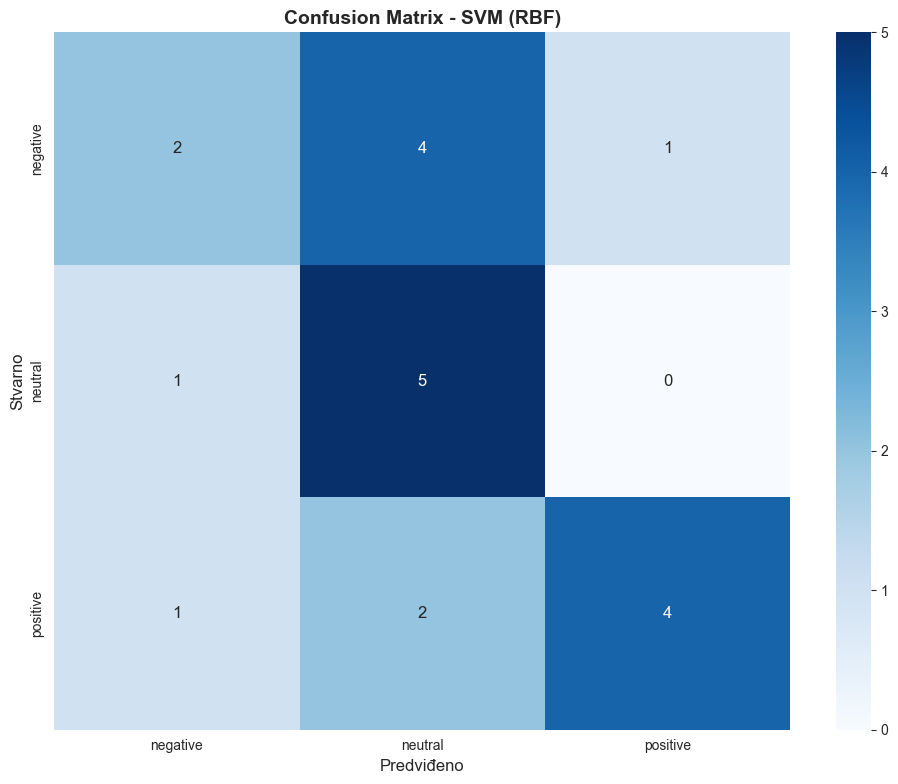

Grafik sačuvan: results/figures/svm_confusion_matrix.png


In [14]:
# Confusion Matrix za SVM
fig_svm_cm = plot_confusion_matrix(y_test, y_pred_svm, labels=sentiment_labels, model_name="SVM (RBF)")
plt.show()

# Sačuvaj
save_figure(fig_svm_cm, 'svm_confusion_matrix.png')

## 4. Poređenje Modela

In [15]:
# Kreiraj tabelu sa rezultatima
metrics_list = [nb_metrics, svm_metrics]
results_table = create_results_table(metrics_list)

print("\n" + "="*60)
print("POREĐENJE MODELA")
print("="*60)
print("\n", results_table.to_string(index=False))
print("\n" + "="*60)


POREĐENJE MODELA

       model_name accuracy precision recall f1_score
     Naive Bayes   0.5500    0.6343 0.5500   0.5204
SVM (RBF kernel)   0.5500    0.5914 0.5500   0.5371



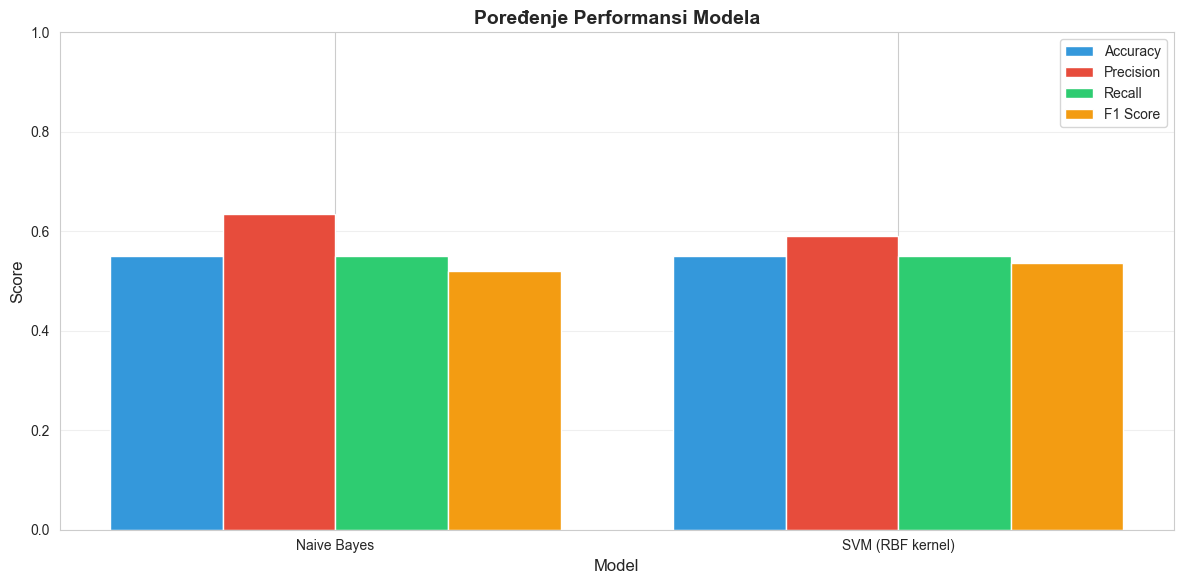

Grafik sačuvan: results/figures/models_comparison.png


In [16]:
# Vizualizacija poređenja
fig_comparison = plot_metrics_comparison(metrics_list)
plt.show()

# Sačuvaj
save_figure(fig_comparison, 'models_comparison.png')

In [22]:
# Analiza grešaka - primeri pogrešnih predikcija
print("\n" + "="*60)
print("ANALIZA GREŠAKA - Naive Bayes")
print("="*60)

# Broj pogrešnih predikcija
num_wrong = (y_test != y_pred_nb).sum()
accuracy = (len(y_test) - num_wrong) / len(y_test) * 100

print(f"\nBroj pogrešnih predikcija: {num_wrong}")
print(f"Tačnost: {accuracy:.2f}%")

# Prikaži primere
if num_wrong > 0:
    print("\n🔍 Primeri pogrešnih predikcija:")
    count = 0
    for i in range(len(y_test)):
        if y_test.iloc[i] != y_pred_nb[i]:
            count += 1
            if count <= 5:  # Prikaži prvih 5
                print(f"\n[Primer {count}]")
                print(f"Text: {X_test.iloc[i]}")
                print(f"Stvarno: {y_test.iloc[i]}")
                print(f"Predviđeno: {y_pred_nb[i]}")
                print("-" * 60)
            else:
                break


ANALIZA GREŠAKA - Naive Bayes

Broj pogrešnih predikcija: 9
Tačnost: 55.00%

🔍 Primeri pogrešnih predikcija:

[Primer 1]
Text: carbon footprint bitcoin unacceptable
Stvarno: negative
Predviđeno: neutral
------------------------------------------------------------

[Primer 2]
Text: central bank trying kill bitcoin cbdc
Stvarno: negative
Predviđeno: neutral
------------------------------------------------------------

[Primer 3]
Text: tether fud spreading bitcoin going
Stvarno: negative
Predviđeno: positive
------------------------------------------------------------

[Primer 4]
Text: sound money principle restored bitcoin
Stvarno: positive
Predviđeno: negative
------------------------------------------------------------

[Primer 5]
Text: excited bitcoin halving next year
Stvarno: positive
Predviđeno: neutral
------------------------------------------------------------


## 5. Čuvanje Modela i Rezultata

In [23]:
# Sačuvaj Naive Bayes model
save_model(nb_model, 'naive_bayes_model.pkl')
save_metrics(nb_metrics, 'naive_bayes_metrics.json')

Model sačuvan: results/models/naive_bayes_model.pkl
Metrike sačuvane: results/metrics/naive_bayes_metrics.json


In [19]:
# Sačuvaj SVM model
save_model(svm_model, 'svm_model.pkl')
save_metrics(svm_metrics, 'svm_metrics.json')

Model sačuvan: results/models/svm_model.pkl
Metrike sačuvane: results/metrics/svm_metrics.json


In [20]:
# Sačuvaj poređenje
results_table.to_csv('../results/metrics/baseline_comparison.csv', index=False)
print("\n✅ Tabela sa poređenjem sačuvana: results/metrics/baseline_comparison.csv")


✅ Tabela sa poređenjem sačuvana: results/metrics/baseline_comparison.csv


## 6. Test Predikcija na Novim Podacima

In [21]:
# Test na custom primerima
test_tweets = [
    "Bitcoin is the future of money!",
    "I lost all my savings on Bitcoin",
    "Bitcoin price stable today",
    "Buying more Bitcoin this is amazing",
    "Crypto is a scam stay away"
]

print("\n" + "="*60)
print("TEST PREDIKCIJA NA NOVIM PRIMERIMA")
print("="*60)

nb_predictions = nb_model.predict(test_tweets)
svm_predictions = svm_model.predict(test_tweets)

for i, tweet in enumerate(test_tweets):
    print(f"\n[Tweet {i+1}]: {tweet}")
    print(f"  Naive Bayes: {nb_predictions[i]}")
    print(f"  SVM:         {svm_predictions[i]}")
    print("-" * 60)


TEST PREDIKCIJA NA NOVIM PRIMERIMA

[Tweet 1]: Bitcoin is the future of money!
  Naive Bayes: positive
  SVM:         positive
------------------------------------------------------------

[Tweet 2]: I lost all my savings on Bitcoin
  Naive Bayes: negative
  SVM:         negative
------------------------------------------------------------

[Tweet 3]: Bitcoin price stable today
  Naive Bayes: neutral
  SVM:         neutral
------------------------------------------------------------

[Tweet 4]: Buying more Bitcoin this is amazing
  Naive Bayes: positive
  SVM:         positive
------------------------------------------------------------

[Tweet 5]: Crypto is a scam stay away
  Naive Bayes: negative
  SVM:         negative
------------------------------------------------------------


## 📝 Zaključak Notebook-a 03

**Urađeno**:
- ✅ Treniran Naive Bayes model
- ✅ Treniran SVM model
- ✅ Evaluacija oba modela
- ✅ Poređenje performansi
- ✅ Analiza grešaka
- ✅ Sačuvani modeli i rezultati

**Rezultati**:
- Naive Bayes Accuracy: {}%
- SVM Accuracy: {}%
- Najbolji model: {}

**Sledeći korak**: Notebook 04 - BERT transformer model (napredni deep learning pristup)